In [1]:
import random
import dotenv
import pathlib
import os
random.seed(2024)
dotenv.load_dotenv(override=True)
HOME_DIR = os.getenv("HOME_DIR")  # directs to gpfs in scratch

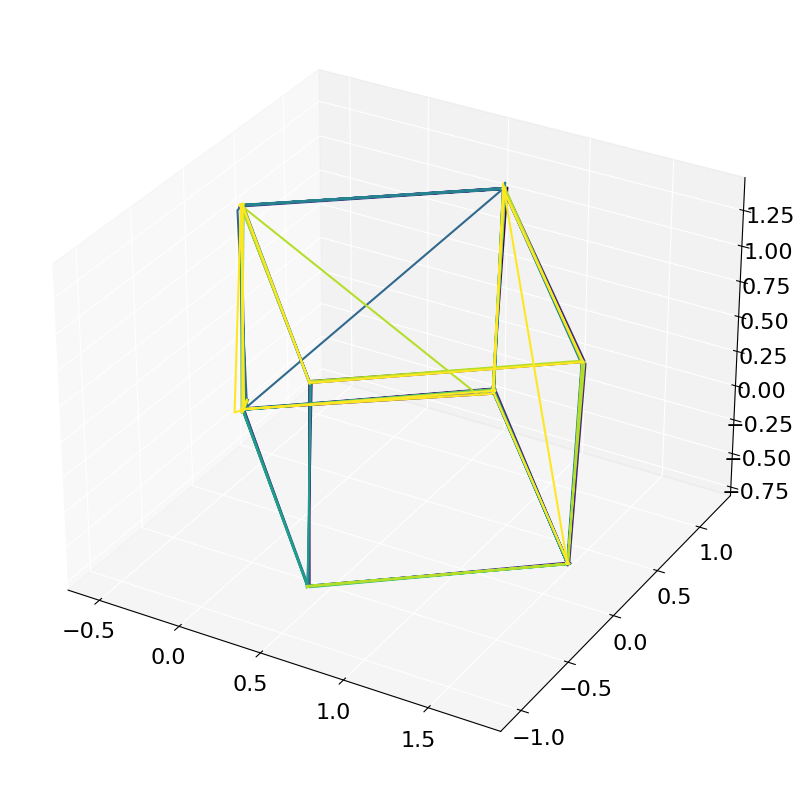

In [2]:
from ctd.comparison.analysis.tt.tt import Analysis_TT

path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250312_3BFF_NODE/max_epochs=1000_weight_decay=1.00E-10_learning_rate=1.00E-02_seed=0_noise=1.00E-01_latent_size=3_layer_hidden_size=64"
node_3bff = Analysis_TT(run_name = "node_3bff", filepath = path + "/")

# node_3bff.plot_trial_io(num_trials = 2)
node_3bff.plot_trial_latents(num_trials = 10)

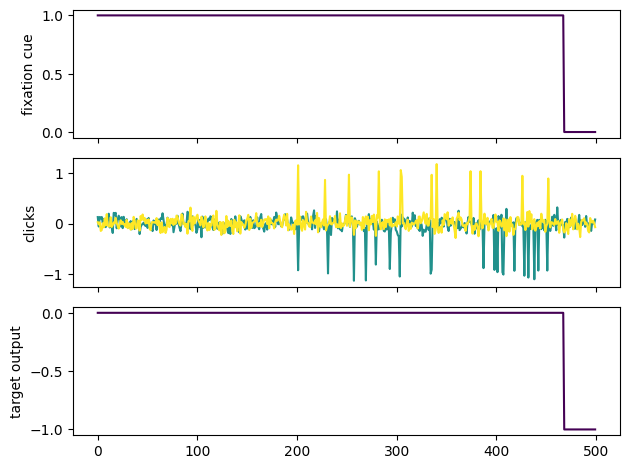

In [1]:
## Pclicks task - just like Luo et al 2023
from ctd.task_modeling.task_env.task_env import PClicks

pc = PClicks(n_timesteps= 500, noise= 0.1, rateL=30)  # Hz

pc.render()

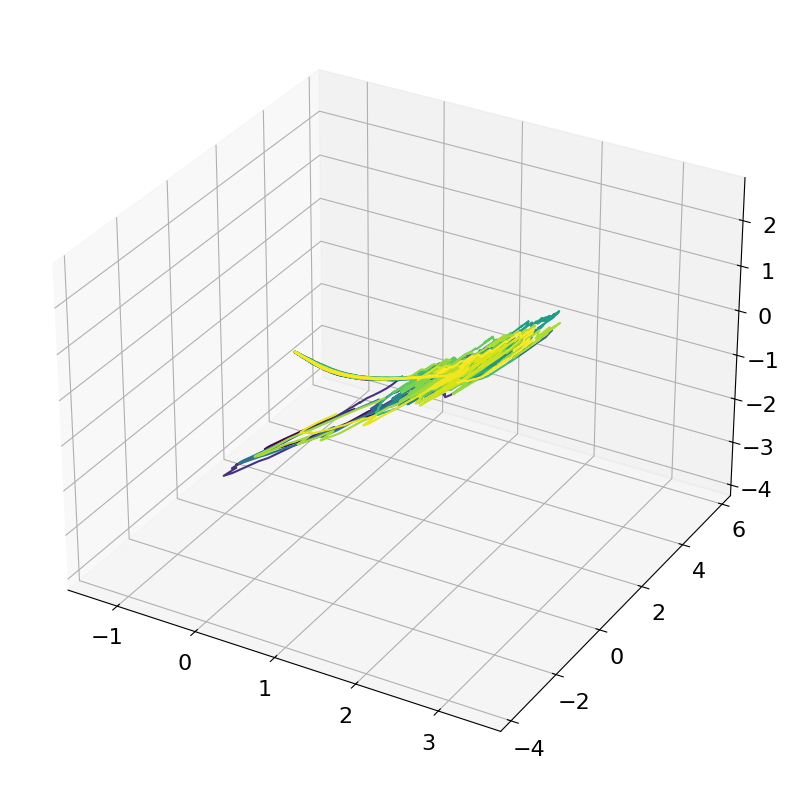

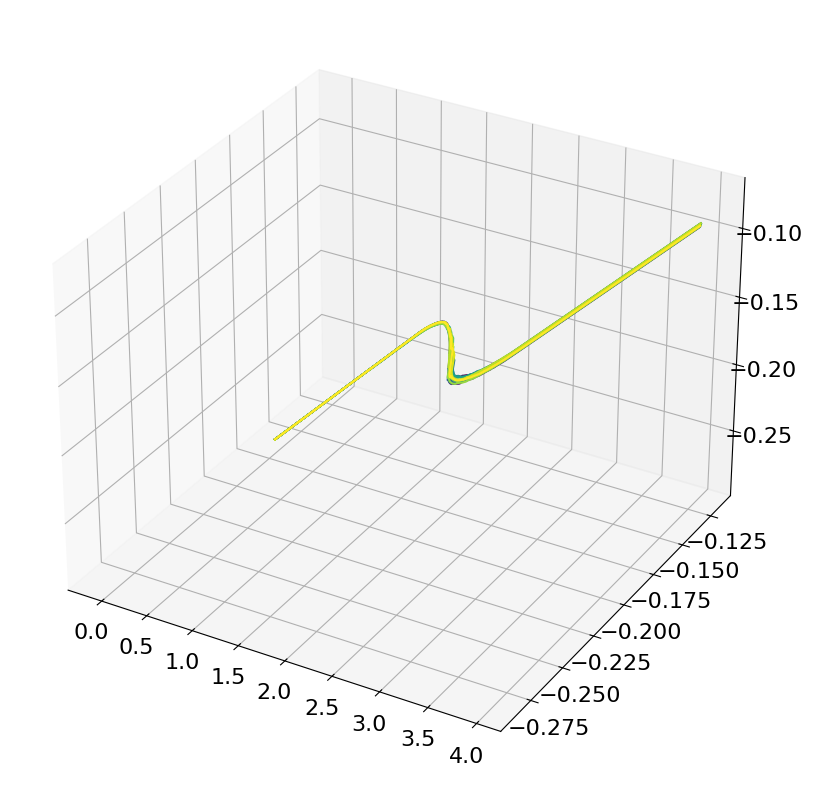

In [6]:
# first very short training on PClicks - loss was 0 always and something is prob wrong
from ctd.comparison.analysis.tt.tt import Analysis_TT

# 39:1 ratio should be very easy
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250316_PClicks_NODE"
tune39 = "max_epochs=250_weight_decay=1.00E-10_learning_rate=1.00E-02_seed=0_noise=5.00E-02_rateL=39_latent_size=3_layer_hidden_size=64_latent_l2_wt=1.00E-10"
tune26 = "max_epochs=250_weight_decay=1.00E-10_learning_rate=1.00E-03_seed=0_noise=5.00E-02_rateL=26_latent_size=3_layer_hidden_size=64_latent_l2_wt=1.00E-10"

node_pclicks_39 = Analysis_TT(run_name = "node_pclicks_26", filepath = path + "/" + tune39 + "/")
node_pclicks_26 = Analysis_TT(run_name = "node_pclicks_26", filepath = path + "/" + tune26 + "/")

# node_pclicks_39.plot_trial_io(num_trials = 3)
# node_pclicks_26.plot_trial_io(num_trials = 3)

# NOTE that running pca takes maximum variance and plotting the trajectories might magnify any noise in them

# choose pca and/or tsne when >3 latents
node_pclicks_26.plot_trial_latents(num_trials = 50, reduce_3_latents=False, pca=True)
node_pclicks_39.plot_trial_latents(num_trials = 20, reduce_3_latents=False, pca=True)

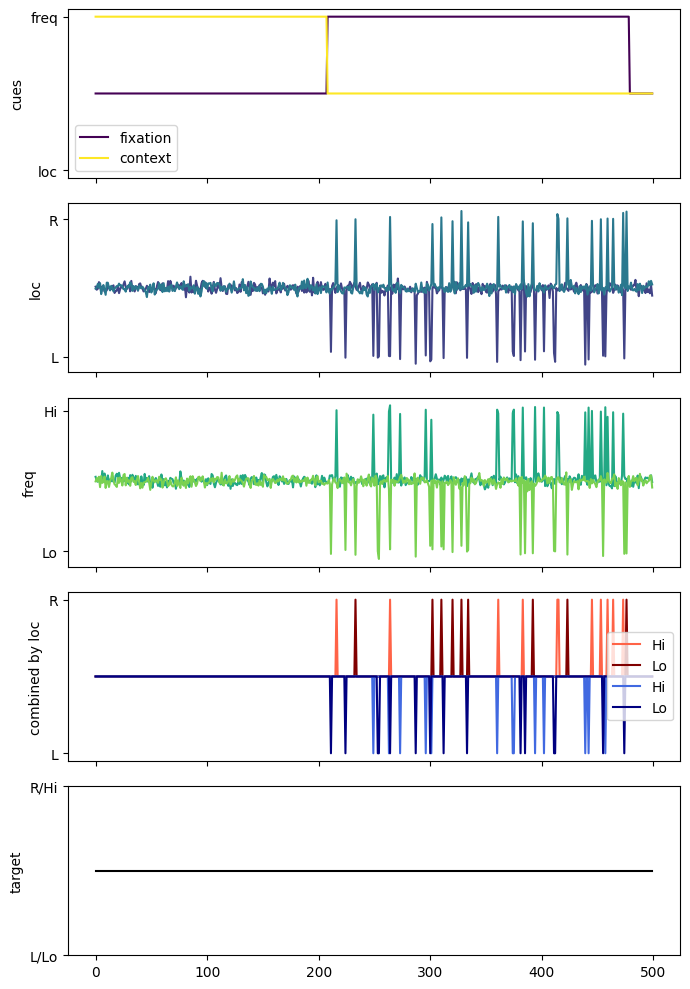

In [8]:
## Marino Pagan task - just like the paper
# note that there is a very small but non-zero chance that the target output should be 0 (if everything has tied)

from ctd.task_modeling.task_env.task_env import MarinoPagan

mp = MarinoPagan(n_timesteps= 500, noise= 0.05, rateL=20)  # Hz

mp.render()